In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Customer data — 15 customers, 2 features
data = {
    'CustomerID': ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8',
                   'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'C15'],
    'AnnualSpending':  [15, 18, 20, 22, 25,      # Group 1: Low spend, frequent
                        80, 85, 90, 88, 82,      # Group 2: High spend, medium frequency
                        45, 48, 50, 52, 47],     # Group 3: Medium spend, low frequency
    'VisitsPerMonth':  [12, 14, 11, 13, 15,      # Group 1: Frequent visitors
                        6, 5, 7, 8, 6,           # Group 2: Medium visits
                        2, 3, 2, 1, 3]           # Group 3: Rare visitors
}

df = pd.DataFrame(data)
print(df)

   CustomerID  AnnualSpending  VisitsPerMonth
0          C1              15              12
1          C2              18              14
2          C3              20              11
3          C4              22              13
4          C5              25              15
5          C6              80               6
6          C7              85               5
7          C8              90               7
8          C9              88               8
9         C10              82               6
10        C11              45               2
11        C12              48               3
12        C13              50               2
13        C14              52               1
14        C15              47               3


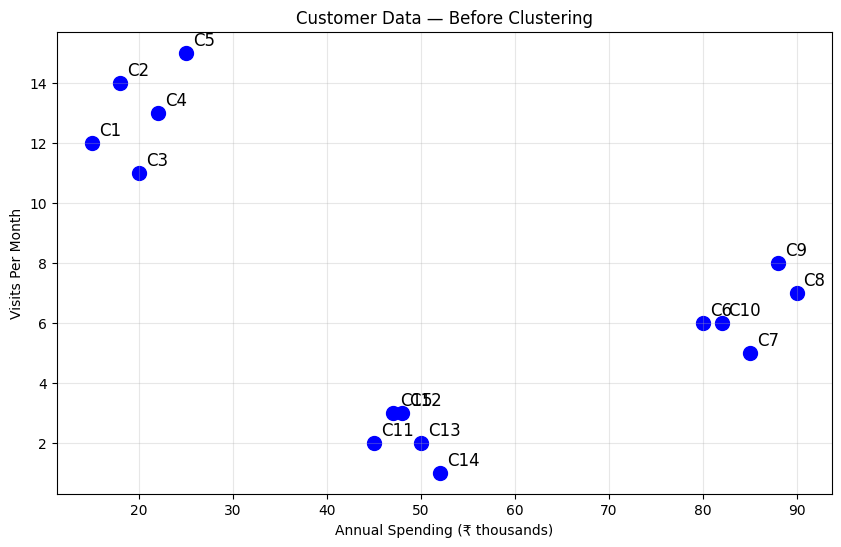

In [2]:
plt.figure(figsize=(10, 6))
plt.scatter(df['AnnualSpending'], df['VisitsPerMonth'], s=100, color='blue')

# Label each point
for i, txt in enumerate(df['CustomerID']):
    plt.annotate(txt, (df['AnnualSpending'][i], df['VisitsPerMonth'][i]),
                 fontsize=12, xytext=(5, 5), textcoords='offset points')

plt.xlabel('Annual Spending (₹ thousands)')
plt.ylabel('Visits Per Month')
plt.title('Customer Data — Before Clustering')
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
# Extract features
X = df[['AnnualSpending', 'VisitsPerMonth']].values

# Simple min-max scaling to [0, 1]
X_scaled = X.copy().astype(float)
X_scaled[:, 0] = (X[:, 0] - X[:, 0].min()) / (X[:, 0].max() - X[:, 0].min())
X_scaled[:, 1] = (X[:, 1] - X[:, 1].min()) / (X[:, 1].max() - X[:, 1].min())

print("Scaled features (first 5 rows):")
print(X_scaled)

Scaled features (first 5 rows):
[[0.         0.78571429]
 [0.04       0.92857143]
 [0.06666667 0.71428571]
 [0.09333333 0.85714286]
 [0.13333333 1.        ]
 [0.86666667 0.35714286]
 [0.93333333 0.28571429]
 [1.         0.42857143]
 [0.97333333 0.5       ]
 [0.89333333 0.35714286]
 [0.4        0.07142857]
 [0.44       0.14285714]
 [0.46666667 0.07142857]
 [0.49333333 0.        ]
 [0.42666667 0.14285714]]


In [8]:
def euclidean_distance(p1, p2):
    """Compute Euclidean distance between two points."""
    return np.sqrt(np.sum((p1-p2) **2))

In [9]:
def compute_distance_matrix(X):
    """Build a matrix where entry [i,j] = distance between point i and point j."""
    n = len(X)
    dist_matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            dist_matrix[i, j] = euclidean_distance(X[i], X[j])
    
    return dist_matrix

dist_matrix = compute_distance_matrix(X_scaled)
print("Distance matrix shape:", dist_matrix.shape)
print("\nDistance matrix (first 5x5):")
print(np.round(dist_matrix[:5, :5], 3))

Distance matrix shape: (15, 15)

Distance matrix (first 5x5):
[[0.    0.148 0.098 0.118 0.252]
 [0.148 0.    0.216 0.089 0.118]
 [0.098 0.216 0.    0.145 0.293]
 [0.118 0.089 0.145 0.    0.148]
 [0.252 0.118 0.293 0.148 0.   ]]


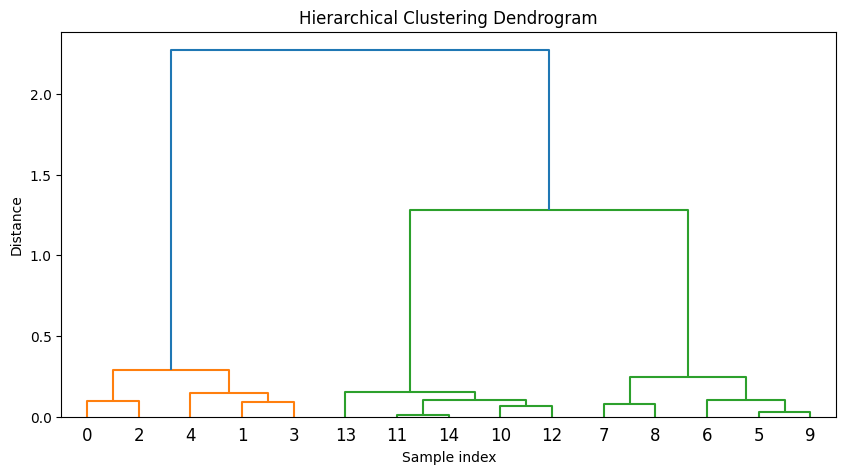

In [10]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt

Z = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()